# Spectral analysis with the Fourier Transform

This tutorial demonstrates how to use the Fourier Transform methods in **earthkit-transforms** to analyse a timeseries in the frequency domain. We use an hourly 2m temperature dataset for two locations (Reading and Vancouver) to show that every step works when the data hold more than one time-series. We will:

1. compute the forward FFT of an hourly timeseries with `temporal.fft`,
2. inspect the power spectrum and identify the dominant (diurnal) cycle,
3. centre the spectrum with `fftshift`,
4. apply a simple low-pass filter and reconstruct a smoothed signal with `temporal.ifft`, and
5. verify that the forward and inverse transforms round-trip.

The transforms use the `fft` extension of the array namespace of the input data (the Python array API standard), so they run on the native backend of the data and return `xarray` objects.


Text(0.5, 1.0, 'Hourly 2m temperature')

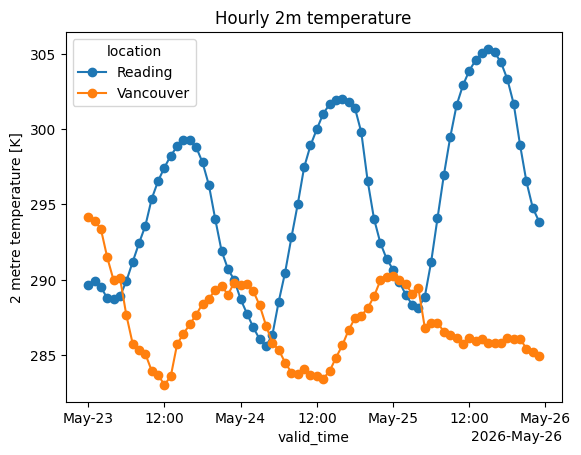

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from earthkit import data as ekd
from earthkit import transforms as ekt

# Hourly 2m temperature timeseries (72 hourly steps over 3 days) for two locations
ds = ekd.from_source("sample", "era5-timeseries-multiple.nc").to_xarray()
da = ds["t2m"]

da.plot.line(x="valid_time", hue="location", marker="o")
plt.title("Hourly 2m temperature")

## 1. Forward transform

`temporal.fft` detects the time dimension (`valid_time`) automatically and returns a complex-valued result indexed by a `frequency` dimension.

Because `valid_time` is a datetime coordinate, the sample spacing is known in seconds and the frequency coordinate is therefore in Hz. That is worth stating explicitly: had the time axis been numeric — *hours since* some epoch, say — the frequencies would be in the reciprocal of *those* units, and `temporal.fft` would leave the coordinate unlabelled rather than assert a unit it cannot verify.

The forward transform also records which dimension it consumed, so the inverse transforms further down restore `valid_time` without being told its name.

In [2]:
spectrum = ekt.temporal.fft(da)

spectrum

<xarray.DataArray 't2m' (location: 2, frequency: 72)> Size: 1kB
array([[ 2.1254309e+04+0.0000000e+00j,  3.6181873e+01+8.3899078e+01j,
         1.8603952e+01+3.0636444e+01j, -1.9632404e+02+1.7992714e+02j,
         1.4326304e-01-1.8276188e+01j,  2.1387093e-02-3.5564790e+00j,
         1.5857482e+00+7.8525548e+00j, -8.0988111e+00-1.5550503e-01j,
        -9.4715452e+00+3.8258581e+00j,  1.0177716e+01-1.7595097e+01j,
         3.9469767e-01+5.0195365e+00j, -6.0290465e+00+3.9161768e+00j,
         4.1107635e+00-3.0908978e+00j, -1.7498523e+00+1.9973781e+00j,
        -1.5209463e+00+3.6424193e-01j, -4.9151093e-01+2.5865140e+00j,
        -3.2336328e+00+1.4347422e+00j, -8.6006445e-01+6.3981169e-01j,
        -4.4917297e+00+5.6923523e+00j, -6.9665194e-01+1.0354474e+00j,
        -2.8036752e+00+8.2415718e-01j, -2.4032340e+00+1.9318168e+00j,
        -1.5208218e+00+3.7614647e-01j, -3.4489987e+00+6.1524749e-01j,
        -2.9255829e+00-4.9863592e-01j, -2.0512412e+00+1.5625035e+00j,
        -2.7773783e+00+9.0367144e-01j, -1.7438781e+00+6.6997933e-01j,
        -2.3840063e+00+1.4095925e+00j, -1.4071045e+00+4.2337486e-01j,
        -2.3490539e+00+3.8001978e-01j, -1.9792778e+00+1.1325877e+00j,
        -1.9649117e+00+8.0021866e-02j, -2.6341197e+00+1.8611387e+00j,
        -1.6150200e+00+3.7647539e-01j, -2.0705647e+00+2.7284950e-01j,
        -1.4873657e+00+0.0000000e+00j, -2.0705647e+00-2.7284950e-01j,
        -1.6150200e+00-3.7647539e-01j, -2.6341197e+00-1.8611387e+00j,
...
         3.3342636e+00-7.5709748e-01j,  3.9378946e+00-3.4953864e+00j,
         7.0458374e+00+0.0000000e+00j,  3.9378946e+00+3.4953864e+00j,
         3.3342636e+00+7.5709748e-01j,  4.1351085e+00+5.7629734e-01j,
         6.5165482e+00+4.2519426e+00j,  5.2331686e+00+1.1988643e+00j,
         4.1306710e+00-6.4817798e-01j,  5.9292765e+00+1.3905396e+00j,
         6.2371111e+00+4.1921296e+00j,  2.4984152e+00+1.4556694e+00j,
         6.0015163e+00-9.3847111e-02j,  8.3524342e+00+1.7980209e-01j,
         5.0460968e+00+1.2276534e+00j, -7.9135495e-01-3.3581141e-01j,
         2.5643332e+00+2.1924560e+00j,  4.8464308e+00+4.2031631e+00j,
         1.2470086e+00+4.9645925e+00j,  3.0266280e+00+4.8894978e+00j,
         2.4633484e+00+4.8388977e+00j,  5.9868159e+00+9.7102814e+00j,
         4.1866784e+00+9.8468170e+00j,  7.3318734e+00+7.1961112e+00j,
         1.2184740e+01+3.8871851e+00j,  3.8162334e+00+7.8611465e+00j,
         2.4574432e+00+8.2752104e+00j,  4.1127281e+00+1.3927075e+01j,
         2.9748662e+00+9.7654457e+00j,  8.7244854e+00+1.8474651e+01j,
         4.5798087e+00+9.3347626e+00j, -1.0071405e+00+1.3520410e+01j,
         7.6392264e+00+2.5833572e+01j,  6.9707084e+00+3.3821907e+01j,
         1.0047634e+01+3.6517815e+01j,  1.0002118e+02+3.7337396e+00j,
        -2.1079220e+01+1.4808721e+01j,  1.6877066e+01-4.4522767e+00j]],
      dtype=complex64)
Coordinates:
  * location    (location) <U9 72B 'Reading' 'Vancouver'
    latitude    (location) float64 16B ...
    longitude   (location) float64 16B ...
    utc_offset  (location) timedelta64[s] 16B ...
  * frequency   (frequency) float64 576B 0.0 3.858e-06 ... -7.716e-06 -3.858e-06
    period      (frequency) float64 576B nan 2.592e+05 ... -1.296e+05 -2.592e+05
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

## 2. Power spectrum and the dominant cycle

The squared amplitude of each frequency component gives the power spectrum. We keep the positive frequencies and read the period of each component directly from the `period` coordinate that `temporal.fft` attaches (`1 / frequency`, in seconds), converting to hours to make the result easier to interpret.

Reading: dominant period 24.0 hours
Vancouver: dominant period 24.0 hours


Text(0.5, 1.0, 'Power spectrum')

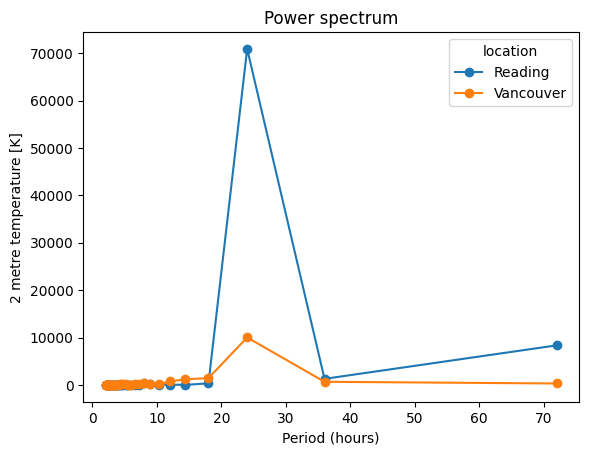

In [3]:
positive = spectrum.where(spectrum["frequency"] > 0, drop=True)
power = (np.abs(positive) ** 2).rename("power")

# The `period` coordinate is in seconds; express it in hours for readability
period_hours = positive["period"] / 3600.0
power = power.assign_coords(period_hours=("frequency", period_hours.data))

# Dominant period for each timeseries (one per location)
dominant_period = period_hours.isel(frequency=power.argmax("frequency"))
for location in dominant_period["location"].values:
    period = float(dominant_period.sel(location=location))
    print(f"{location}: dominant period {period:.1f} hours")

power.plot.line(x="period_hours", hue="location", marker="o")
plt.xlabel("Period (hours)")
plt.title("Power spectrum")

The strongest peak is close to 24 hours, reflecting the diurnal cycle of near-surface temperature.

## 3. Centre the spectrum with `fftshift`

The raw FFT output orders the frequencies from zero upwards and then wraps around to the negative frequencies. `temporal.fftshift` reorders the data (and its frequency coordinate) so that the zero-frequency component is in the centre, which is often more convenient for plotting. Its inverse, `temporal.ifftshift`, restores the original ordering.

fftshift round-trips: True


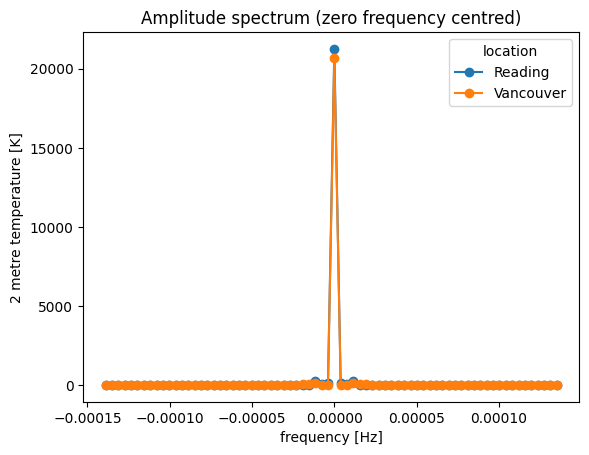

In [4]:
shifted = ekt.temporal.fftshift(spectrum, freq_dim="frequency")

np.abs(shifted).plot.line(x="frequency", hue="location", marker="o")
plt.title("Amplitude spectrum (zero frequency centred)")

# ifftshift undoes the reordering
restored_order = ekt.temporal.ifftshift(shifted, freq_dim="frequency")
print("fftshift round-trips:", bool(np.allclose(restored_order, spectrum)))

## 4. Low-pass filter and inverse transform

We can filter in the frequency domain and transform back to the time domain. Here we keep only the low-frequency components (periods of 12 hours or longer) by setting the higher frequencies to zero, then reconstruct a smoothed signal with `temporal.ifft`.

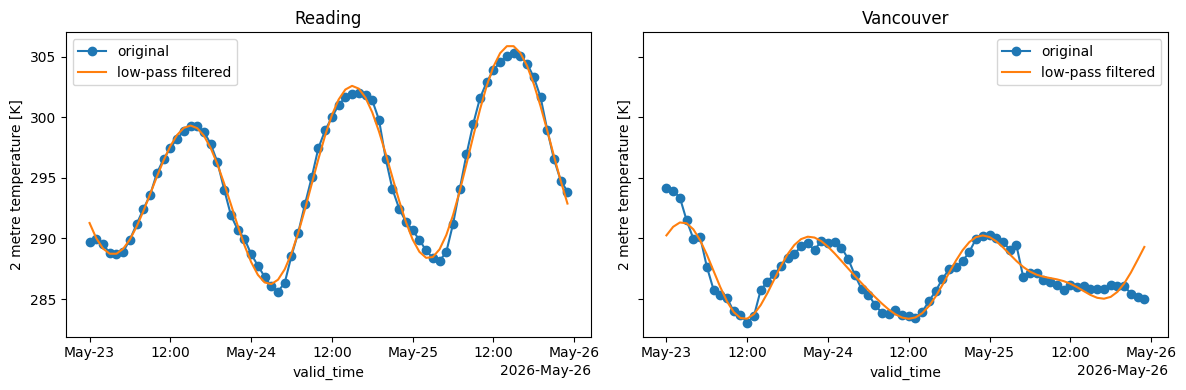

In [5]:
# Keep components with a period of 12 hours or longer
cutoff_hz = 1.0 / (12 * 3600.0)
filtered = spectrum.where(np.abs(spectrum["frequency"]) <= cutoff_hz, 0)

smoothed = ekt.temporal.ifft(filtered, time_coord=da["valid_time"].values).real

# One panel per location so the original and filtered signals stay legible
fig, axes = plt.subplots(1, da.sizes["location"], figsize=(12, 4), sharey=True)
for ax, location in zip(np.atleast_1d(axes), da["location"].values):
    da.sel(location=location).plot.line(x="valid_time", marker="o", label="original", ax=ax)
    smoothed.sel(location=location).plot.line(x="valid_time", label="low-pass filtered", ax=ax)
    ax.set_title(str(location))
    ax.legend()
fig.tight_layout()

## 5. Round-trip verification

Applying the inverse transform to the full spectrum recovers the original signal (up to floating-point precision — the data are `float32`, and the transforms preserve that precision rather than promoting to `float64`). Note that `time_dim` is not needed: `temporal.ifft` restores the `valid_time` dimension that `temporal.fft` recorded.

In [6]:
restored = ekt.temporal.ifft(spectrum, time_coord=da["valid_time"].values).real

print("Maximum absolute difference:", float(np.abs(restored - da).max()))

Maximum absolute difference: 6.103515625e-05


## 6. Real-valued transforms with `rfft`/`irfft`

The temperature signal is real-valued, so we can use `temporal.rfft` instead of `temporal.fft`. It returns only the non-negative frequencies (length `n // 2 + 1`), which roughly halves the size of the output by dropping the redundant negative-frequency half. The inverse `temporal.irfft` reconstructs the real signal directly, without needing to take the real part.

A half-spectrum of length `m` could have come from a signal of `2m - 2` or `2m - 1` points, so inverting one is ambiguous in general. `temporal.rfft` records the length it started from, so `temporal.irfft` recovers it exactly — here 72 points, but equally 71 had the series been odd. Pass `n` when inverting a spectrum that this module did not produce, or one that has been sliced.

fft frequencies:  72
rfft frequencies: 37


Text(0.5, 1.0, 'Power spectrum (rfft)')

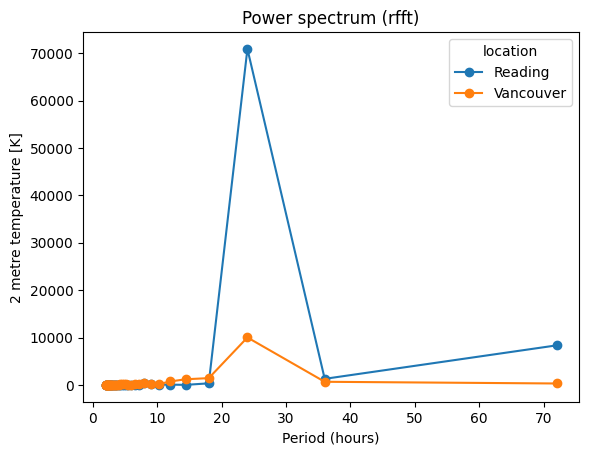

In [7]:
rspectrum = ekt.temporal.rfft(da)

print(f"fft frequencies:  {spectrum.sizes['frequency']}")
print(f"rfft frequencies: {rspectrum.sizes['frequency']}")

rpower = (np.abs(rspectrum) ** 2).rename("power")
rperiod_hours = rspectrum["period"] / 3600.0
rpower = rpower.assign_coords(period_hours=("frequency", rperiod_hours.data))

rpower.where(rspectrum["frequency"] > 0, drop=True).plot.line(x="period_hours", hue="location", marker="o")
plt.xlabel("Period (hours)")
plt.title("Power spectrum (rfft)")

In [8]:
restored_r = ekt.temporal.irfft(rspectrum, time_coord=da["valid_time"].values)

print("Maximum absolute difference:", float(np.abs(restored_r - da).max()))

Maximum absolute difference: 6.103515625e-05


## 7. Building frequency axes with `fftfreq`/`rfftfreq`

The sample-frequency helpers return the frequency coordinate for a given window length and sample spacing as a standalone `xarray.DataArray`, without computing a transform. They also carry the matching `period` coordinate (`1 / frequency`). This is handy for labelling or selecting frequencies. `fftfreq` matches the output of `fft` (positive and negative frequencies) while `rfftfreq` matches `rfft` (non-negative only). With hourly data the sample spacing is 3600 seconds.

Matches rfft coordinate: True


Text(0.5, 1.0, 'rfftfreq sample periods')

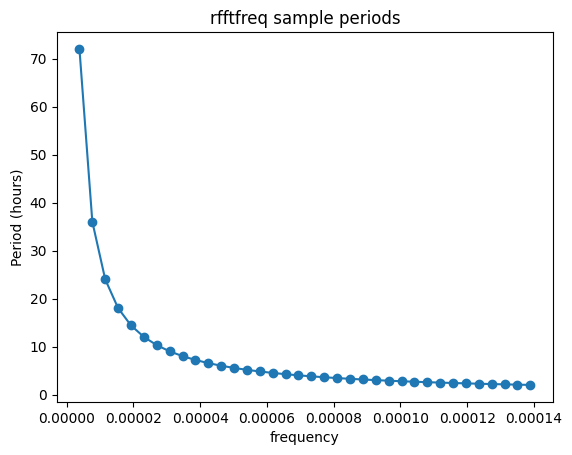

In [9]:
n = da.sizes["valid_time"]
freqs = ekt.temporal.rfftfreq(n, sample_spacing=3600.0)

# The helper reproduces the frequency coordinate computed by rfft
print("Matches rfft coordinate:", bool(np.allclose(freqs, rspectrum["frequency"])))

# The `period` coordinate is in seconds; express it in hours
periods = freqs["period"] / 3600.0
periods.plot.line(marker="o")
plt.ylabel("Period (hours)")
plt.title("rfftfreq sample periods")

## 8. Hermitian-symmetric transforms with `ihfft`/`hfft`

Because a real signal has a Hermitian-symmetric spectrum, `temporal.ihfft` returns the compact non-negative-frequency half, and `temporal.hfft` transforms such a Hermitian half back to a real time series. The two are inverses of one another, so applying them in sequence recovers the original signal.

In [10]:
hermitian = ekt.temporal.ihfft(da)
restored_h = ekt.temporal.hfft(hermitian, time_coord=da["valid_time"].values)

print("Maximum absolute difference:", float(np.abs(restored_h - da).max()))

Maximum absolute difference: 6.103515625e-05


## Beyond the time dimension

Every transform shown here is also available generically in the `earthkit.transforms.fourier` module, where the dimension is specified explicitly (for example `earthkit.transforms.fourier.fft(dataarray, dim="longitude")`). Both namespaces expose the n-dimensional transforms (`fftn`/`ifftn`/`rfftn`/`irfftn`), which are most useful when transforming over several dimensions at once, for example latitude and longitude together for a 2-D spatial spectrum.